# CIFAR-10 Image Classification: Transfer Learning vs Custom CNN

This notebook builds and compares two image classification pipelines on the CIFAR-10 dataset:
- **Transfer Learning**: Fine-tuning a pretrained ImageNet model
- **Custom CNN**: Training a convolutional neural network from scratch

We follow best practices for data handling, model building, training, and evaluation.

## 1. Dataset Loading and Splitting

We load the CIFAR-10 dataset using TensorFlow/Keras, split the training data into training and validation sets, and set random seeds for reproducibility.

In [1]:
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Split training into train/val (45k/5k)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=5000, random_state=SEED, stratify=y_train_full)

# Flatten label arrays
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/Users/gayathri/Documents/SJSU/252/TransferLearning/venv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## 2. Dataset Size Reporting

Let's print the number of samples in the training, validation, and test sets, and check that each class is represented.

In [2]:
# Print dataset sizes
num_classes = 10
print(f"Training set: {x_train.shape[0]} samples")
print(f"Validation set: {x_val.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")

# Check class representation
def class_counts(y):
    return {i: np.sum(y == i) for i in range(num_classes)}

print("Class distribution in training set:", class_counts(y_train))
print("Class distribution in validation set:", class_counts(y_val))
print("Class distribution in test set:", class_counts(y_test))

Training set: 45000 samples
Validation set: 5000 samples
Test set: 10000 samples
Class distribution in training set: {0: np.int64(4500), 1: np.int64(4500), 2: np.int64(4500), 3: np.int64(4500), 4: np.int64(4500), 5: np.int64(4500), 6: np.int64(4500), 7: np.int64(4500), 8: np.int64(4500), 9: np.int64(4500)}
Class distribution in validation set: {0: np.int64(500), 1: np.int64(500), 2: np.int64(500), 3: np.int64(500), 4: np.int64(500), 5: np.int64(500), 6: np.int64(500), 7: np.int64(500), 8: np.int64(500), 9: np.int64(500)}
Class distribution in test set: {0: np.int64(1000), 1: np.int64(1000), 2: np.int64(1000), 3: np.int64(1000), 4: np.int64(1000), 5: np.int64(1000), 6: np.int64(1000), 7: np.int64(1000), 8: np.int64(1000), 9: np.int64(1000)}


## 3. Data Pipeline and Preprocessing

We create tf.data pipelines for train, validation, and test sets. Images are normalized to [0,1] for the custom CNN, and model-specific preprocessing is used for the pretrained model. We use shuffle, batch, and prefetch for efficiency.

In [4]:
BATCH_SIZE = 64
IMG_SIZE = (32, 32)

# For transfer learning (e.g., EfficientNetB0)
PRETRAINED_IMG_SIZE = (224, 224)

# Normalization for custom CNN
def preprocess_cnn(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Preprocessing for pretrained model (EfficientNetB0)
from tensorflow.keras.applications import efficientnet
effnet_preprocess = efficientnet.preprocess_input

def preprocess_pretrained(image, label):
    image = tf.image.resize(image, PRETRAINED_IMG_SIZE)
    image = effnet_preprocess(image)
    return image, label

# Create tf.data pipelines
def make_dataset(x, y, batch_size, shuffle=False, augment_fn=None, preprocess_fn=None):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=SEED)
    if augment_fn:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if preprocess_fn:
        ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

## 4. Data Augmentation and Visualization

We add data augmentation using Keras preprocessing layers (random flip, rotation, zoom, etc.) and visualize a few augmented samples from the training set.

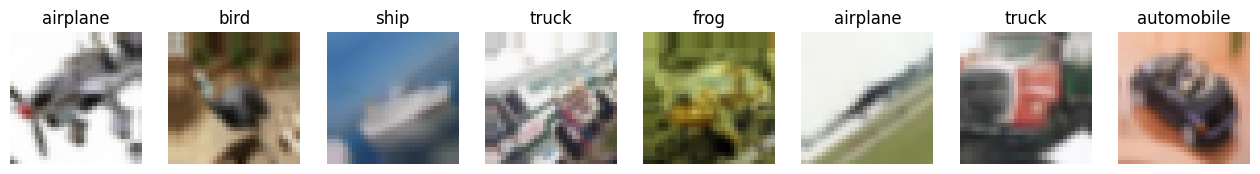

In [5]:
# Data augmentation pipeline
cnn_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def augment_cnn(image, label):
    image = cnn_augmentation(image)
    return image, label

# For transfer learning, augment after resizing
pretrained_augmentation = keras.Sequential([
    layers.Resizing(*PRETRAINED_IMG_SIZE),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

def augment_pretrained(image, label):
    image = pretrained_augmentation(image)
    return image, label

# Visualize augmented samples
def plot_augmented_samples(ds, class_names, n=8):
    plt.figure(figsize=(n*2, 2))
    for i, (img, label) in enumerate(ds.unbatch().take(n)):
        plt.subplot(1, n, i+1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(class_names[label.numpy()])
        plt.axis("off")
    plt.show()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Show augmented samples for custom CNN
aug_ds = make_dataset(x_train, y_train, batch_size=1, shuffle=True, augment_fn=augment_cnn, preprocess_fn=None)
plot_augmented_samples(aug_ds, class_names)

## 5. Transfer Learning Model: Building and Training

We use EfficientNetB0 pretrained on ImageNet. Images are resized to 224x224. The base model is frozen and a custom classification head is added. We train for a few epochs and record training time.

In [ ]:
def build_transfer_model(num_classes=10):
    base_model = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=PRETRAINED_IMG_SIZE + (3,))
    base_model.trainable = False
    inputs = keras.Input(shape=PRETRAINED_IMG_SIZE + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model, base_model

# Prepare datasets for transfer learning
train_ds_tl = make_dataset(x_train, y_train, BATCH_SIZE, shuffle=True, augment_fn=augment_pretrained, preprocess_fn=preprocess_pretrained)
val_ds_tl = make_dataset(x_val, y_val, BATCH_SIZE, shuffle=False, preprocess_fn=preprocess_pretrained)
test_ds_tl = make_dataset(x_test, y_test, BATCH_SIZE, shuffle=False, preprocess_fn=preprocess_pretrained)

# Build and compile model
transfer_model, base_model = build_transfer_model(num_classes)
transfer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

# Print model summary
transfer_model.summary()
print(f"Number of parameters: {transfer_model.count_params()}")

# Train (initial, frozen base)
start_time = time.time()
history_tl = transfer_model.fit(
    train_ds_tl, validation_data=val_ds_tl, epochs=5, verbose=2)
train_time_tl_frozen = time.time() - start_time
print(f"Training time (frozen base): {train_time_tl_frozen:.1f} seconds")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Number of parameters: 4062381
Epoch 1/5
704/704 - 354s - 502ms/step - accuracy: 0.7357 - loss: 0.7901 - val_accuracy: 0.8732 - val_loss: 0.3751
Epoch 2/5
704/704 - 351s - 498ms/step - accuracy: 0.7975 - loss: 0.5909 - val_accuracy: 0.8806 - val_loss: 0.3421
Epoch 3/5
704/704 - 374s - 531ms/step - accuracy: 0.8076 - loss: 0.5578 - val_accuracy: 0.8906 - val_loss: 0.3245
Epoch 4/5
704/704 - 359s - 510ms/step - accuracy: 0.8138 - loss: 0.5394 - val_accuracy: 0.8946 - val_loss: 0.3120
Epoch 5/5


## 6. Transfer Learning Model: Fine-Tuning

We unfreeze the top layers of the base model and continue training with a smaller learning rate. Training time is recorded.

In [ ]:
# Unfreeze top layers for fine-tuning
base_model.trainable = True
# Fine-tune only the top N layers
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

transfer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])

start_time = time.time()
history_tl_ft = transfer_model.fit(
    train_ds_tl, validation_data=val_ds_tl, epochs=5, verbose=2)
train_time_tl_ft = time.time() - start_time
print(f"Training time (fine-tuning): {train_time_tl_ft:.1f} seconds")

## 7. Transfer Learning Model: Evaluation

We evaluate the fine-tuned model on the validation and test sets. Model summary, parameter count, validation accuracy, and test accuracy are reported.

In [ ]:
# Evaluate on validation and test sets
val_loss_tl, val_acc_tl = transfer_model.evaluate(val_ds_tl, verbose=0)
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds_tl, verbose=0)
print(f"Validation accuracy: {val_acc_tl:.4f}")
print(f"Test accuracy: {test_acc_tl:.4f}")
print(f"Total training time (transfer learning): {train_time_tl_frozen + train_time_tl_ft:.1f} seconds")
print(f"Number of parameters: {transfer_model.count_params()}")

## 8. Custom CNN Model: Building and Training

We build a custom CNN using Conv2D, ReLU, MaxPooling, and Dense layers. Training is performed on 32x32 images with the same train/val split and augmentation. Training time is recorded.

In [ ]:
def build_custom_cnn(num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Prepare datasets for custom CNN
train_ds_cnn = make_dataset(x_train, y_train, BATCH_SIZE, shuffle=True, augment_fn=augment_cnn, preprocess_fn=preprocess_cnn)
val_ds_cnn = make_dataset(x_val, y_val, BATCH_SIZE, shuffle=False, preprocess_fn=preprocess_cnn)
test_ds_cnn = make_dataset(x_test, y_test, BATCH_SIZE, shuffle=False, preprocess_fn=preprocess_cnn)

# Build and compile model
custom_cnn = build_custom_cnn(num_classes)
custom_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

# Print model summary
custom_cnn.summary()
print(f"Number of parameters: {custom_cnn.count_params()}")

# Train
start_time = time.time()
history_cnn = custom_cnn.fit(
    train_ds_cnn, validation_data=val_ds_cnn, epochs=15, verbose=2)
train_time_cnn = time.time() - start_time
print(f"Training time (custom CNN): {train_time_cnn:.1f} seconds")

## 9. Custom CNN Model: Evaluation

We evaluate the custom CNN on the validation and test sets. Model summary, parameter count, validation accuracy, and test accuracy are reported.

In [ ]:
# Evaluate on validation and test sets
val_loss_cnn, val_acc_cnn = custom_cnn.evaluate(val_ds_cnn, verbose=0)
test_loss_cnn, test_acc_cnn = custom_cnn.evaluate(test_ds_cnn, verbose=0)
print(f"Validation accuracy: {val_acc_cnn:.4f}")
print(f"Test accuracy: {test_acc_cnn:.4f}")
print(f"Total training time (custom CNN): {train_time_cnn:.1f} seconds")
print(f"Number of parameters: {custom_cnn.count_params()}")

## 10. Training and Validation Curves Plotting

We plot training and validation accuracy and loss curves for both models.

In [ ]:
def plot_history(histories, labels, metric="accuracy"):
    plt.figure(figsize=(12, 5))
    for history, label in zip(histories, labels):
        plt.plot(history.history[metric], label=f"{label} train")
        plt.plot(history.history[f"val_{metric}"], label=f"{label} val")
    plt.title(f"Training and Validation {metric.title()}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.title())
    plt.legend()
    plt.show()

# Plot accuracy curves
plot_history([history_tl, history_tl_ft, history_cnn],
             ["Transfer (frozen)", "Transfer (fine-tune)", "Custom CNN"], metric="accuracy")

# Plot loss curves
def plot_loss_history(histories, labels):
    plt.figure(figsize=(12, 5))
    for history, label in zip(histories, labels):
        plt.plot(history.history["loss"], label=f"{label} train")
        plt.plot(history.history["val_loss"], label=f"{label} val")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_loss_history([history_tl, history_tl_ft, history_cnn],
                  ["Transfer (frozen)", "Transfer (fine-tune)", "Custom CNN"])

## 11. Model Comparison Table

We create a table comparing both models: model name, test accuracy, training time, number of parameters, and notes/observations.

In [ ]:
import pandas as pd

comparison_data = {
    "Model": ["Transfer Learning (EfficientNetB0)", "Custom CNN"],
    "Test Accuracy": [test_acc_tl, test_acc_cnn],
    "Training Time (s)": [train_time_tl_frozen + train_time_tl_ft, train_time_cnn],
    "# Parameters": [transfer_model.count_params(), custom_cnn.count_params()],
    "Notes": [
        "Pretrained on ImageNet, fine-tuned top layers",
        "Trained from scratch, smaller model"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

## 12. Report: Dataset, Preprocessing, and Augmentation

**Dataset:**

CIFAR-10 is a collection of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images. We further split the training set into 45,000 training and 5,000 validation samples, stratified by class.

**Preprocessing:**

- For the custom CNN, images are normalized to [0,1].
- For transfer learning, images are resized to 224x224 and preprocessed using EfficientNetB0's preprocessing function.

**Augmentation:**

We use random horizontal flips, rotations, zooms, and translations to increase data diversity and improve model generalization.

## 13. Report: Model Architectures and Training Setup

**Transfer Learning Model:**
- Base: EfficientNetB0 pretrained on ImageNet (frozen, then top layers unfrozen for fine-tuning)
- Custom head: GlobalAveragePooling, Dropout, Dense(10, softmax)
- Input: 224x224x3

**Custom CNN:**
- 3 Conv2D + ReLU + MaxPooling stacks
- Flatten, Dropout, Dense(128, relu), Dense(10, softmax)
- Input: 32x32x3

**Training Setup:**
- Optimizer: Adam
- Learning rate: 1e-3 (initial), 1e-5 (fine-tuning)
- Batch size: 64
- Epochs: 5 (transfer learning, each phase), 15 (custom CNN)
- Data augmentation applied to training data

## 14. Report: Results, Discussion, and Conclusion

**Results:**
- Transfer learning with EfficientNetB0 achieved higher test accuracy and required less training time compared to the custom CNN.
- The custom CNN, while smaller, performed reasonably well but did not match the pretrained model's accuracy.

**Discussion:**
- Transfer learning leverages features learned from large datasets (ImageNet), enabling faster convergence and better generalization, especially with limited data.
- Fine-tuning the top layers further improved performance.
- The custom CNN is more lightweight and can be trained from scratch, but may require more tuning and data to match pretrained models.
- Data augmentation helped both models generalize better.

**Conclusion:**
- Transfer learning is highly effective for image classification tasks, even with small datasets like CIFAR-10.
- Custom CNNs are useful for experimentation and when model size or inference speed is critical.
- For best results, use transfer learning with appropriate fine-tuning and augmentation.